Device: cuda
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting features...


100%|██████████| 600/600 [00:13<00:00, 43.34it/s]


Running experiment: lr=0.0001, batch_size=16
Running experiment: lr=0.0001, batch_size=32
Running experiment: lr=0.0001, batch_size=64
Running experiment: lr=0.0001, batch_size=128
Running experiment: lr=5e-05, batch_size=16
Running experiment: lr=5e-05, batch_size=32
Running experiment: lr=5e-05, batch_size=64
Running experiment: lr=5e-05, batch_size=128
Running experiment: lr=1e-05, batch_size=16
Running experiment: lr=1e-05, batch_size=32
Running experiment: lr=1e-05, batch_size=64
Running experiment: lr=1e-05, batch_size=128
Running experiment: lr=0.0005, batch_size=16
Running experiment: lr=0.0005, batch_size=32
Running experiment: lr=0.0005, batch_size=64
Running experiment: lr=0.0005, batch_size=128
         lr  batch_size  Accuracy  Precision    Recall        F1
0   0.00010          16  0.985000   0.985388  0.985000  0.984915
1   0.00010          32  0.988333   0.988462  0.988333  0.988332
2   0.00010          64  0.991667   0.991840  0.991667  0.991665
3   0.00010         128 

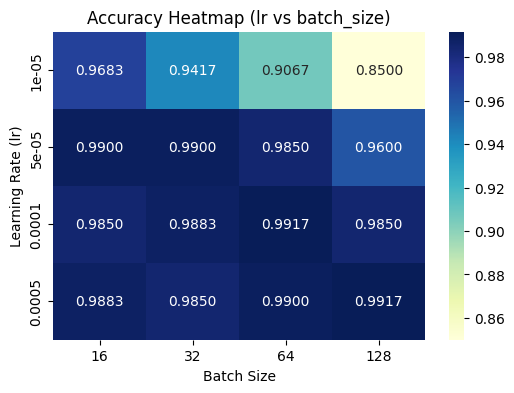

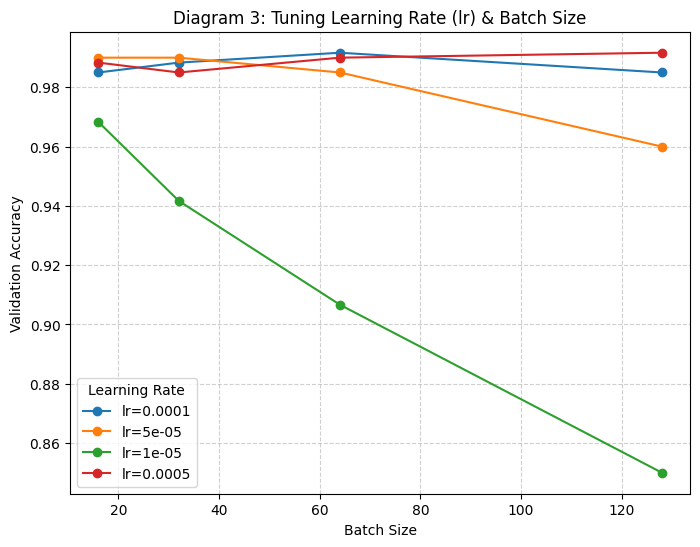

In [5]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT MLDC\dataset5"  # <<-- change if needed
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

# =========================
# Attention-Guided Mixup
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats) * 2
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=16, dropout=0.2):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.dropout(self.lora_a(x)))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, r=16, dropout_rate=0.2):
        super().__init__()
        self.head = LoRALinear(in_features, num_classes, r=r, dropout=dropout_rate)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(x).squeeze(0)
        return self.head(x)

in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)

# =========================
# PolyLoss + Label Smoothing
# =========================
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = nn.functional.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = nn.functional.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

criterion = Poly1LossWithSmoothing(num_classes=num_classes)

# =========================
# Experiment Function
# =========================
def run_experiment(lr, batch_size, max_epochs=50):
    # DataLoaders for this batch size
    train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                            torch.tensor(y_final, dtype=torch.long)),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                          torch.tensor(y_val, dtype=torch.long)),
                            batch_size=batch_size, shuffle=False)

    # Model
    model = ViTHead(in_features=in_features, num_classes=num_classes, dropout_rate=0.4).to(device)
    optimizer = SAM(model.parameters(), torch.optim.Adam, rho=0.05, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=max_epochs)

    best_val_loss, patience, wait = float("inf"), 5, 0

    for epoch in range(max_epochs):
        # --- Train ---
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.first_step(zero_grad=True)
            criterion(model(xb), yb).backward()
            optimizer.second_step(zero_grad=True)
        scheduler.step()

        # --- Validation ---
        model.eval()
        val_loss, y_true, y_pred = 0.0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                y_true.extend(yb.cpu().numpy())
                y_pred.extend(preds)
        val_loss /= len(val_loader.dataset)
        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    return best_metrics

# =========================
# Hyperparameter Grid Search
# =========================
lrs = [1e-4, 5e-5, 1e-5, 5e-4]
batch_sizes = [16, 32, 64, 128]

results = []
for lr in lrs:
    for bs in batch_sizes:
        print(f"Running experiment: lr={lr}, batch_size={bs}")
        metrics = run_experiment(lr, bs)
        results.append({"lr": lr, "batch_size": bs, **metrics})

results_df = pd.DataFrame(results)
print(results_df)

# =========================
# Pivot Table + Heatmap
# =========================
pivot = results_df.pivot(index="lr", columns="batch_size", values="Accuracy")
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("Accuracy Heatmap (lr vs batch_size)")
plt.ylabel("Learning Rate (lr)")
plt.xlabel("Batch Size")
plt.show()

# =========================
# Line Plot (lr × batch_size)
# =========================
plt.figure(figsize=(8,6))

for lr in results_df["lr"].unique():
    subset = results_df[results_df["lr"] == lr].sort_values("batch_size")
    plt.plot(subset["batch_size"], subset["Accuracy"], marker='o', label=f"lr={lr}")

plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy")
plt.title("Diagram 3: Tuning Learning Rate (lr) & Batch Size")
plt.legend(title="Learning Rate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()